## lecture flow

1. `Dataset` 과 `DataLoader`의 역할 이해
2. 시계열에서 **슬라이딩 윈도우(windowing)** 가 왜 필요한지 이해
3. `seq_len`, `label_len`, `pred_len`이 각각 무슨 뜻인지 이해
4. `train/val/test split`, **scaling**, **time feature**, **features='S'/'M'/'MS'** 를 이해
5. 마지막으로 **TSLib 스타일의 `Dataset_ETT_hour`를 직접 만들어보고 배치까지 확인**

## 참고문헌

- PyTorch 공식 문서: `Dataset` / `DataLoader`
- TSLib:
  - `data_provider/data_loader.py`
  - `data_provider/data_factory.py`
  - `utils/timefeatures.py`
  - `exp/exp_long_term_forecasting.py`

In [1]:
import os
import math
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)


numpy: 2.4.3
pandas: 2.2.3
torch: 2.4.1+cu124


## 학습 목표 (반드시 알아야할것!)

1. `Dataset` 과 `DataLoader`는 왜 분리되어 있을까?
2. 시계열 예측에서 `__getitem__`은 왜 한 점이 아니라 **한 구간(window)** 을 반환할까?
3. `seq_len`, `label_len`, `pred_len`은 각각 무엇을 의미할까?
4. 왜 validation/test split의 시작점을 `seq_len`만큼 앞으로 당겨둘까?
5. 왜 scaling은 전체 데이터가 아니라 **train 구간으로만 fit** 해야 할까?
6. `seq_x`, `seq_y`, `seq_x_mark`, `seq_y_mark` 네 가지 반환값은 각각 무엇일까?
7. `features='S'`, `'M'`, `'MS'`는 dataset 단계와 loss 단계에서 어떻게 다르게 동작할까?


# 1. `Dataset` 과 `DataLoader`를 왜 나눌까?

PyTorch 관점에서 핵심은 아주 간단합니다.

- `Dataset`: **샘플 1개를 어떻게 꺼낼지** 정의하는 객체
- `DataLoader`: 그 `Dataset`을 받아서 **batching, shuffling, iteration** 을 담당하는 객체

시계열에서는 “샘플 1개”가 이미지 1장이 아니라, 보통 **입력 구간 1개 + 예측 대상 구간 1개** 입니다.
그래서 `Dataset_ETT_hour`의 핵심은 결국:

> “인덱스 하나를 받았을 때, 시계열 구간을 어떻게 잘라서 모델에 넘길까?”

입니다.


In [2]:
# 아주 순수한 Python 리스트로 batching을 손으로 해보자.
raw_values = list(range(20))
batch_size = 4

manual_batches = [raw_values[i:i+batch_size] for i in range(0, len(raw_values), batch_size)]

print("원본 데이터:", raw_values)
print("손으로 만든 batch:")
for i, batch in enumerate(manual_batches):
    print(f"  batch {i}: {batch}")


원본 데이터: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
손으로 만든 batch:
  batch 0: [0, 1, 2, 3]
  batch 1: [4, 5, 6, 7]
  batch 2: [8, 9, 10, 11]
  batch 3: [12, 13, 14, 15]
  batch 4: [16, 17, 18, 19]


위처럼 작은 예시는 손으로 잘 되지만, 실제 학습에서는 금방 불편해집니다.

- 매 epoch마다 섞기(shuffle)
- batch size 바꾸기
- 여러 worker로 빠르게 읽기
- dataset의 샘플 정의와 batching 로직을 분리하기

이런 이유로 PyTorch는 `Dataset` 과 `DataLoader`를 나눕니다.


In [3]:
class TinyNumberDataset(Dataset):
    def __init__(self, values):
        self.values = list(values)

    def __len__(self):
        return len(self.values)

    def __getitem__(self, idx):
        # 샘플 1개를 어떻게 꺼낼지 정의
        x = self.values[idx]
        y = x * 10
        return x, y

tiny_ds = TinyNumberDataset(range(10))

print("len(tiny_ds) =", len(tiny_ds))
print("tiny_ds[0] =", tiny_ds[0])
print("tiny_ds[3] =", tiny_ds[3])


len(tiny_ds) = 10
tiny_ds[0] = (0, 0)
tiny_ds[3] = (3, 30)


In [4]:
tiny_loader = DataLoader(tiny_ds, batch_size=4, shuffle=False)

for batch_idx, batch in enumerate(tiny_loader):
    x, y = batch
    print(f"batch {batch_idx}")
    print("  x:", x)
    print("  y:", y)


batch 0
  x: tensor([0, 1, 2, 3])
  y: tensor([ 0, 10, 20, 30])
batch 1
  x: tensor([4, 5, 6, 7])
  y: tensor([40, 50, 60, 70])
batch 2
  x: tensor([8, 9])
  y: tensor([80, 90])


여기서 이미 중요한 감각을 하나 잡아야 합니다.

- `Dataset`은 **한 샘플**
- `DataLoader`는 **그 샘플들을 모아서 batch**

시계열에서도 똑같습니다.  
단지 시계열의 “한 샘플”은 숫자 하나가 아니라 **구간(window)** 일 뿐입니다.


# 2. 시계열에서 샘플 1개는 왜 "구간(window)"일까?

예를 들어 길이 20짜리 시계열이 있고,

- `seq_len = 6`
- `label_len = 2`
- `pred_len = 3`

라고 해봅시다.

그러면 한 샘플은 대략 이런 모양입니다.

- 입력(`seq_x`): 과거 6개
- 출력(`seq_y`): **마지막 2개(label_len)** + 앞으로 예측할 3개(pred_len)

즉, `seq_y` 길이는 `label_len + pred_len = 5` 입니다.


In [5]:
tiny_series = np.arange(20)

seq_len = 6
label_len = 2
pred_len = 3

def slice_window(values, index, seq_len, label_len, pred_len):
    s_begin = index
    s_end = s_begin + seq_len

    r_begin = s_end - label_len
    r_end = r_begin + label_len + pred_len

    seq_x = values[s_begin:s_end]
    seq_y = values[r_begin:r_end]

    return {
        "index": index,
        "s_begin": s_begin,
        "s_end": s_end,
        "r_begin": r_begin,
        "r_end": r_end,
        "seq_x": seq_x,
        "seq_y": seq_y,
    }

examples = [slice_window(tiny_series, i, seq_len, label_len, pred_len) for i in [0, 1, 2, 5]]

for ex in examples:
    print("=" * 70)
    print(f"index={ex['index']}")
    print(f"s_begin={ex['s_begin']}, s_end={ex['s_end']}")
    print(f"r_begin={ex['r_begin']}, r_end={ex['r_end']}")
    print("seq_x:", ex["seq_x"])
    print("seq_y:", ex["seq_y"])


index=0
s_begin=0, s_end=6
r_begin=4, r_end=9
seq_x: [0 1 2 3 4 5]
seq_y: [4 5 6 7 8]
index=1
s_begin=1, s_end=7
r_begin=5, r_end=10
seq_x: [1 2 3 4 5 6]
seq_y: [5 6 7 8 9]
index=2
s_begin=2, s_end=8
r_begin=6, r_end=11
seq_x: [2 3 4 5 6 7]
seq_y: [ 6  7  8  9 10]
index=5
s_begin=5, s_end=11
r_begin=9, r_end=14
seq_x: [ 5  6  7  8  9 10]
seq_y: [ 9 10 11 12 13]


위 출력을 보면 `seq_y`의 앞부분이 `seq_x`의 뒷부분과 겹칩니다.

이 겹치는 길이가 바로 `label_len` 입니다.

이건 TSLib의 encoder-decoder 계열 모델에서,  
decoder가 **직전의 일부 실제 값**(`label_len`)을 보고 시작하도록 만들기 위한 구조입니다.


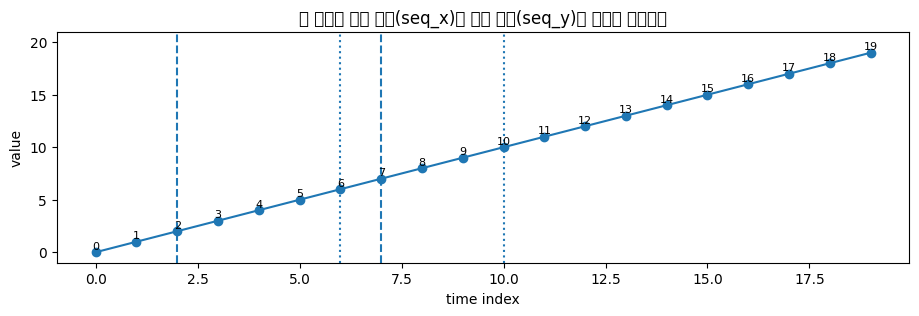

index=2일 때
seq_x = [2 3 4 5 6 7]
seq_y = [ 6  7  8  9 10]
겹치는 구간(label_len) = [6 7]
실제로 예측해야 하는 미래(pred_len) = [ 8  9 10]


In [6]:
ex = slice_window(tiny_series, index=2, seq_len=seq_len, label_len=label_len, pred_len=pred_len)

plt.figure(figsize=(11, 3))
plt.plot(np.arange(len(tiny_series)), tiny_series, marker="o")
plt.axvline(ex["s_begin"], linestyle="--")
plt.axvline(ex["s_end"] - 1, linestyle="--")
plt.axvline(ex["r_begin"], linestyle=":")
plt.axvline(ex["r_end"] - 1, linestyle=":")

for i, v in enumerate(tiny_series):
    plt.text(i, v + 0.3, str(v), ha="center", fontsize=8)

plt.title("한 샘플이 입력 구간(seq_x)과 출력 구간(seq_y)을 어떻게 자르는가")
plt.xlabel("time index")
plt.ylabel("value")
plt.ylim(tiny_series.min() - 1, tiny_series.max() + 2)
plt.show()

print("index=2일 때")
print("seq_x =", ex["seq_x"])
print("seq_y =", ex["seq_y"])
print("겹치는 구간(label_len) =", ex["seq_y"][:label_len])
print("실제로 예측해야 하는 미래(pred_len) =", ex["seq_y"][label_len:])


### 여기서 꼭 짚고 넘어갈 포인트

원문 `Dataset_ETT_hour`의 핵심 인덱싱은 아래 아이디어입니다.

- `s_begin = index`
- `s_end = s_begin + seq_len`
- `r_begin = s_end - label_len`
- `r_end = r_begin + label_len + pred_len`

즉,

- encoder 입력은 `[index : index + seq_len]`
- decoder 쪽에서 참고할 출력 구간은 `[index + seq_len - label_len : index + seq_len + pred_len]`

이제 이 아이디어를 진짜 `Dataset` 클래스로 옮겨보겠습니다.


In [7]:
class WindowDatasetBasic(Dataset):
    def __init__(self, values, seq_len, label_len, pred_len):
        self.values = np.asarray(values, dtype=np.float32).reshape(-1, 1)
        self.seq_len = seq_len
        self.label_len = label_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.values) - self.seq_len - self.pred_len + 1

    def __getitem__(self, index):
        s_begin = index
        s_end = s_begin + self.seq_len

        r_begin = s_end - self.label_len
        r_end = r_begin + self.label_len + self.pred_len

        seq_x = self.values[s_begin:s_end]
        seq_y = self.values[r_begin:r_end]
        return seq_x, seq_y

basic_ds = WindowDatasetBasic(tiny_series, seq_len=6, label_len=2, pred_len=3)

print("dataset 길이:", len(basic_ds))
print("첫 샘플 shapes:", basic_ds[0][0].shape, basic_ds[0][1].shape)
print("첫 샘플 seq_x:\n", basic_ds[0][0].reshape(-1))
print("첫 샘플 seq_y:\n", basic_ds[0][1].reshape(-1))


dataset 길이: 12
첫 샘플 shapes: (6, 1) (5, 1)
첫 샘플 seq_x:
 [0. 1. 2. 3. 4. 5.]
첫 샘플 seq_y:
 [4. 5. 6. 7. 8.]


In [8]:
basic_loader = DataLoader(basic_ds, batch_size=3, shuffle=False)

batch_x, batch_y = next(iter(basic_loader))

print("batch_x shape:", batch_x.shape)  # [B, seq_len, feature_dim]
print("batch_y shape:", batch_y.shape)  # [B, label_len + pred_len, feature_dim]
print()
print("batch_x[0].squeeze() =", batch_x[0].squeeze())
print("batch_y[0].squeeze() =", batch_y[0].squeeze())


batch_x shape: torch.Size([3, 6, 1])
batch_y shape: torch.Size([3, 5, 1])

batch_x[0].squeeze() = tensor([0., 1., 2., 3., 4., 5.])
batch_y[0].squeeze() = tensor([4., 5., 6., 7., 8.])


## 왜 `__len__ = N - seq_len - pred_len + 1` 일까?

가장 자주 헷갈리는 부분이라 꼭 직접 확인해보는 것이 좋습니다.

데이터 길이를 `N`이라고 하면, 시작 인덱스 `index`는 다음 조건을 만족해야 합니다.

- 입력 끝: `index + seq_len`
- 미래 예측 구간 끝: `index + seq_len + pred_len`

즉 마지막 시작점은:

- `index_max = N - seq_len - pred_len`

가능한 시작 인덱스 개수는 0부터 `index_max`까지니까:

- `N - seq_len - pred_len + 1`

입니다.


In [9]:
N = len(tiny_series)
expected_len = N - seq_len - pred_len + 1

print("N =", N)
print("expected_len =", expected_len)
print("len(basic_ds) =", len(basic_ds))
assert expected_len == len(basic_ds)


N = 20
expected_len = 12
len(basic_ds) = 12


# 3. 시계열에서는 값만이 아니라 시간 정보도 필요하다

`Dataset_ETT_hour`는 값 시퀀스만 반환하지 않습니다.  
아래 네 가지를 반환합니다.

1. `seq_x`: 입력 값 구간
2. `seq_y`: decoder용 출력 구간 (`label_len + pred_len`)
3. `seq_x_mark`: 입력 구간에 해당하는 시간 특징
4. `seq_y_mark`: 출력 구간에 해당하는 시간 특징

즉, **값(value)** 와 **시간 정보(time mark)** 를 분리해서 모델에 넘깁니다.


In [10]:
toy_dates = pd.date_range("2021-01-01 00:00:00", periods=10, freq="H")
toy_stamp = pd.DataFrame({"date": toy_dates})

def make_timeenc0_hourly(df_stamp):
    df = df_stamp.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["weekday"] = df["date"].dt.weekday
    df["hour"] = df["date"].dt.hour
    return df[["month", "day", "weekday", "hour"]].to_numpy(dtype=np.float32)

def make_timeenc1_hourly(dates):
    # TSLib의 hourly time_features 아이디어를 교육용으로 단순화한 구현
    idx = pd.DatetimeIndex(pd.to_datetime(dates))
    hour = idx.hour / 23.0 - 0.5
    weekday = idx.dayofweek / 6.0 - 0.5
    day = (idx.day - 1) / 30.0 - 0.5
    day_of_year = (idx.dayofyear - 1) / 365.0 - 0.5
    return np.vstack([hour, weekday, day, day_of_year]).T.astype(np.float32)

enc0 = make_timeenc0_hourly(toy_stamp)
enc1 = make_timeenc1_hourly(toy_stamp["date"])

print("timeenc=0 (달/일/요일/시):")
display(pd.DataFrame(enc0, columns=["month", "day", "weekday", "hour"]))

print("timeenc=1 (정규화된 연속 특징):")
display(pd.DataFrame(enc1, columns=["hour_norm", "weekday_norm", "day_norm", "dayofyear_norm"]).round(3))


timeenc=0 (달/일/요일/시):


,month,day,weekday,hour
0,1.0,1.0,4.0,0.0
1,1.0,1.0,4.0,1.0
2,1.0,1.0,4.0,2.0
3,1.0,1.0,4.0,3.0
4,1.0,1.0,4.0,4.0
5,1.0,1.0,4.0,5.0
6,1.0,1.0,4.0,6.0
7,1.0,1.0,4.0,7.0
8,1.0,1.0,4.0,8.0
9,1.0,1.0,4.0,9.0


timeenc=1 (정규화된 연속 특징):


,hour_norm,weekday_norm,day_norm,dayofyear_norm
0,-0.500,0.167,-0.5,-0.5
1,-0.457,0.167,-0.5,-0.5
2,-0.413,0.167,-0.5,-0.5
3,-0.370,0.167,-0.5,-0.5
4,-0.326,0.167,-0.5,-0.5
5,-0.283,0.167,-0.5,-0.5
6,-0.239,0.167,-0.5,-0.5
7,-0.196,0.167,-0.5,-0.5
8,-0.152,0.167,-0.5,-0.5
9,-0.109,0.167,-0.5,-0.5


여기서 이해해야 할 핵심은:

- `timeenc=0`: 사람이 이해하기 쉬운 **달/일/요일/시**
- `timeenc=1`: 모델 입력에 더 친화적인 **정규화된 시간 특징**

TSLib의 `ETT_hour`는 `freq='h'`일 때 `HourOfDay`, `DayOfWeek`, `DayOfMonth`, `DayOfYear`를 사용합니다.


In [11]:
class WindowDatasetWithMarks(Dataset):
    def __init__(self, values, dates, seq_len, label_len, pred_len, timeenc=0):
        self.values = np.asarray(values, dtype=np.float32).reshape(-1, 1)
        self.dates = pd.to_datetime(dates)
        self.seq_len = seq_len
        self.label_len = label_len
        self.pred_len = pred_len
        self.timeenc = timeenc

        df_stamp = pd.DataFrame({"date": self.dates})
        if self.timeenc == 0:
            self.marks = make_timeenc0_hourly(df_stamp)
        else:
            self.marks = make_timeenc1_hourly(df_stamp["date"])

    def __len__(self):
        return len(self.values) - self.seq_len - self.pred_len + 1

    def __getitem__(self, index):
        s_begin = index
        s_end = s_begin + self.seq_len

        r_begin = s_end - self.label_len
        r_end = r_begin + self.label_len + self.pred_len

        seq_x = self.values[s_begin:s_end]
        seq_y = self.values[r_begin:r_end]
        seq_x_mark = self.marks[s_begin:s_end]
        seq_y_mark = self.marks[r_begin:r_end]
        return seq_x, seq_y, seq_x_mark, seq_y_mark

toy_values = np.linspace(10, 19, 10)
toy_ds_marks = WindowDatasetWithMarks(
    values=toy_values,
    dates=toy_dates,
    seq_len=4,
    label_len=2,
    pred_len=2,
    timeenc=0,
)

seq_x, seq_y, seq_x_mark, seq_y_mark = toy_ds_marks[0]
print("seq_x shape:", seq_x.shape)
print("seq_y shape:", seq_y.shape)
print("seq_x_mark shape:", seq_x_mark.shape)
print("seq_y_mark shape:", seq_y_mark.shape)

print("\nseq_x_mark:")
display(pd.DataFrame(seq_x_mark, columns=["month", "day", "weekday", "hour"]))

print("seq_y_mark:")
display(pd.DataFrame(seq_y_mark, columns=["month", "day", "weekday", "hour"]))


seq_x shape: (4, 1)
seq_y shape: (4, 1)
seq_x_mark shape: (4, 4)
seq_y_mark shape: (4, 4)

seq_x_mark:


,month,day,weekday,hour
0,1.0,1.0,4.0,0.0
1,1.0,1.0,4.0,1.0
2,1.0,1.0,4.0,2.0
3,1.0,1.0,4.0,3.0


seq_y_mark:


,month,day,weekday,hour
0,1.0,1.0,4.0,2.0
1,1.0,1.0,4.0,3.0
2,1.0,1.0,4.0,4.0
3,1.0,1.0,4.0,5.0


# 4. `Dataset_ETT_hour`를 이해하려면 split과 scaling을 먼저 이해해야 한다

TSLib의 `Dataset_ETT_hour`는 단순히 window만 자르는 것이 아닙니다.

1. **train / val / test 구간을 고정된 방식으로 나눈다**
2. **scaler는 train 구간으로만 fit** 한다
3. val/test도 같은 scaler로 transform 한다
4. 그 위에서 sliding window를 만든다

이 순서를 정확히 이해해야 합니다.


## 4-1. TSLib의 `ETT_hour` split 수치

원문 로직은 아래 수치를 사용합니다.

- train end: `12 * 30 * 24 = 8640`
- val end: `12 * 30 * 24 + 4 * 30 * 24 = 11520`
- test end: `12 * 30 * 24 + 8 * 30 * 24 = 14400`

그리고 validation/test의 시작점은 `seq_len`만큼 앞으로 당겨 둡니다.

왜냐하면 validation/test에서도 첫 샘플을 만들려면,  
해당 split 시작 직전의 **과거 `seq_len` 길이 입력 구간** 이 필요하기 때문입니다.


In [12]:
def ett_hour_borders(seq_len):
    border1s = [
        0,
        12 * 30 * 24 - seq_len,
        12 * 30 * 24 + 4 * 30 * 24 - seq_len,
    ]
    border2s = [
        12 * 30 * 24,
        12 * 30 * 24 + 4 * 30 * 24,
        12 * 30 * 24 + 8 * 30 * 24,
    ]
    return border1s, border2s

seq_len_demo = 96
pred_len_demo = 96

border1s, border2s = ett_hour_borders(seq_len_demo)

split_df = pd.DataFrame({
    "split": ["train", "val", "test"],
    "border1": border1s,
    "border2": border2s,
})
split_df["raw_segment_length"] = split_df["border2"] - split_df["border1"]
split_df["num_windows"] = split_df["raw_segment_length"] - seq_len_demo - pred_len_demo + 1
display(split_df)


,split,border1,border2,raw_segment_length,num_windows
0,train,0,8640,8640,8449
1,val,8544,11520,2976,2785
2,test,11424,14400,2976,2785


> 구현 세부사항 메모  
> ETDataset 저장소 설명은 ETT-small을 장기간(2년) 수집한 데이터로 소개하지만,  
> **TSLib의 `Dataset_ETT_hour` 구현 자체는** `12×30×24`, `4×30×24`, `4×30×24`에 해당하는
> 고정 경계를 사용해 **14400행까지의 구간**을 기준으로 split을 만듭니다.  
> 따라서 이 수업에서는 **데이터셋 소개 문장보다 loader 구현 숫자**를 기준으로 이해하는 것이 중요합니다.


### 강조할 점

`Dataset_ETT_hour` 클래스 안의 기본 길이(default size)는:

- `seq_len = 24 * 4 * 4 = 384`
- `label_len = 24 * 4 = 96`
- `pred_len = 24 * 4 = 96`

입니다.

하지만 `run.py`의 CLI 기본값은 흔히:

- `seq_len = 96`
- `label_len = 48`
- `pred_len = 96`

입니다.

둘이 다른 이유는, 실제 학습에서는 `data_provider()`가  
`size=[args.seq_len, args.label_len, args.pred_len]` 를 **명시적으로 넘겨서 override** 하기 때문입니다.


In [13]:
dataset_default_size = {"seq_len": 24 * 4 * 4, "label_len": 24 * 4, "pred_len": 24 * 4}
cli_default_size = {"seq_len": 96, "label_len": 48, "pred_len": 96}

print("클래스 내부 default size :", dataset_default_size)
print("run.py CLI default size  :", cli_default_size)


클래스 내부 default size : {'seq_len': 384, 'label_len': 96, 'pred_len': 96}
run.py CLI default size  : {'seq_len': 96, 'label_len': 48, 'pred_len': 96}


## 4-2. 왜 scaling은 train으로만 fit해야 할까?

전체 데이터로 scaler를 fit하면,  
미래 구간(val/test)의 평균/분산 정보를 미리 본 셈이 되어 **데이터 누수(data leakage)** 가 발생합니다.


In [14]:
# 데이터 누수를 숫자로 직관적으로 보자.
train_part = np.random.normal(loc=0.0, scale=1.0, size=1000)
test_part = np.random.normal(loc=5.0, scale=1.0, size=200)  # 평균이 크게 다른 미래 구간
all_part = np.concatenate([train_part, test_part])

scaler_train_only = StandardScaler().fit(train_part.reshape(-1, 1))
scaler_all = StandardScaler().fit(all_part.reshape(-1, 1))

summary = pd.DataFrame({
    "segment": ["train", "test"],
    "original_mean": [train_part.mean(), test_part.mean()],
    "scaled_with_train_fit_mean": [
        scaler_train_only.transform(train_part.reshape(-1, 1)).mean(),
        scaler_train_only.transform(test_part.reshape(-1, 1)).mean(),
    ],
    "scaled_with_all_fit_mean": [
        scaler_all.transform(train_part.reshape(-1, 1)).mean(),
        scaler_all.transform(test_part.reshape(-1, 1)).mean(),
    ],
}).round(3)

display(summary)


,segment,original_mean,scaled_with_train_fit_mean,scaled_with_all_fit_mean
0,train,0.019,0.000,-0.397
1,test,5.134,5.225,1.986


해석:

- `train_only`로 fit하면 train은 평균 0 근처로 정규화되고,
- test는 **미래 분포 차이**가 그대로 드러납니다.

반면 전체로 fit하면 test 분포를 이미 알고 정규화하게 되어,  
평가가 지나치게 낙관적일 수 있습니다.

`Dataset_ETT_hour`가 **train split으로만 `StandardScaler.fit(...)`** 하는 이유가 바로 이것입니다.


# 5. 실습용 `ETTh1` 스타일 데이터 만들기

실제 ETTh1 CSV가 있으면 그걸 써도 좋지만,  
지금은 인터넷/경로 문제 없이 바로 실습할 수 있어야 하므로 **synthetic ETTh1-like 데이터** 를 먼저 만듭니다.

중요한 점은 다음입니다.

- 컬럼 구조는 ETTh1와 비슷하게:
  - `date`, `HUFL`, `HULL`, `MUFL`, `MULL`, `LUFL`, `LULL`, `OT`
- 길이는 TSLib의 `Dataset_ETT_hour` 구현이 기대하는 **14400행**
- `OT`를 마지막 컬럼으로 둔다


In [15]:
def make_synthetic_etth1(n_rows=14400, start="2016-07-01 00:00:00"):
    idx = pd.date_range(start=start, periods=n_rows, freq="H")
    t = np.arange(n_rows)

    daily = np.sin(2 * np.pi * t / 24)
    weekly = np.sin(2 * np.pi * t / (24 * 7))
    monthly = np.sin(2 * np.pi * t / (24 * 30))
    slow_trend = t / n_rows

    rng = np.random.default_rng(SEED)

    HUFL = 60 + 10 * daily + 4 * weekly + 2 * monthly + rng.normal(0, 0.8, n_rows)
    HULL = 40 +  8 * daily + 3 * weekly + 1.5 * monthly + rng.normal(0, 0.8, n_rows)
    MUFL = 55 +  7 * daily + 5 * weekly + 1.0 * monthly + rng.normal(0, 0.8, n_rows)
    MULL = 35 +  6 * daily + 4 * weekly + 1.0 * monthly + rng.normal(0, 0.8, n_rows)
    LUFL = 45 +  5 * daily + 2 * weekly + 0.5 * monthly + rng.normal(0, 0.8, n_rows)
    LULL = 25 +  4 * daily + 2 * weekly + 0.5 * monthly + rng.normal(0, 0.8, n_rows)

    # OT는 다른 load 변수들의 영향을 받도록 만들어 보자.
    OT = (
        30
        + 0.12 * HUFL
        + 0.08 * HULL
        + 0.10 * MUFL
        + 0.06 * MULL
        + 0.07 * LUFL
        + 0.05 * LULL
        + 1.5 * weekly
        + 2.0 * slow_trend
        + rng.normal(0, 0.6, n_rows)
    )

    df = pd.DataFrame({
        "date": idx,
        "HUFL": HUFL,
        "HULL": HULL,
        "MUFL": MUFL,
        "MULL": MULL,
        "LUFL": LUFL,
        "LULL": LULL,
        "OT": OT,
    })
    return df

synthetic_df = make_synthetic_etth1()
synthetic_path = Path("synthetic_ETTh1.csv")
synthetic_df.to_csv(synthetic_path, index=False)

print("저장 위치:", synthetic_path.resolve())
print("shape:", synthetic_df.shape)
display(synthetic_df.head())
display(synthetic_df.describe().round(2))


저장 위치: /workspace/synthetic_ETTh1.csv
shape: (14400, 8)


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,60.243774,41.174437,54.768312,35.750803,44.790309,24.226968,52.473061
1,2016-07-01 01:00:00,61.923221,42.147958,57.086517,37.038526,44.460361,25.393904,52.837497
2,2016-07-01 02:00:00,65.934186,43.279476,59.970649,36.774079,46.323286,27.568330,54.883874
3,2016-07-01 03:00:00,68.323731,46.345696,60.605184,38.001908,48.954434,28.650951,55.851654
4,2016-07-01 04:00:00,67.765394,47.285555,61.992917,39.341531,49.928469,30.167986,56.253166


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,14400,14400.00,14400.00,14400.00,14400.00,14400.00,14400.00,14400.00
mean,2017-04-26 23:30:00,60.00,40.03,55.00,35.00,45.01,25.00,53.40
min,2016-07-01 00:00:00,43.07,25.92,40.59,22.77,35.73,16.27,44.27
25%,2016-11-27 23:45:00,53.54,34.81,50.53,31.12,41.77,22.43,50.90
50%,2017-04-26 23:30:00,60.01,40.04,55.01,35.01,44.99,24.96,53.41
75%,2017-09-23 23:15:00,66.50,45.19,59.51,38.85,48.23,27.57,55.87
max,2018-02-20 23:00:00,77.33,53.97,69.62,47.79,54.33,33.21,62.46
std,NaN,7.79,6.19,6.17,5.21,3.91,3.28,3.44


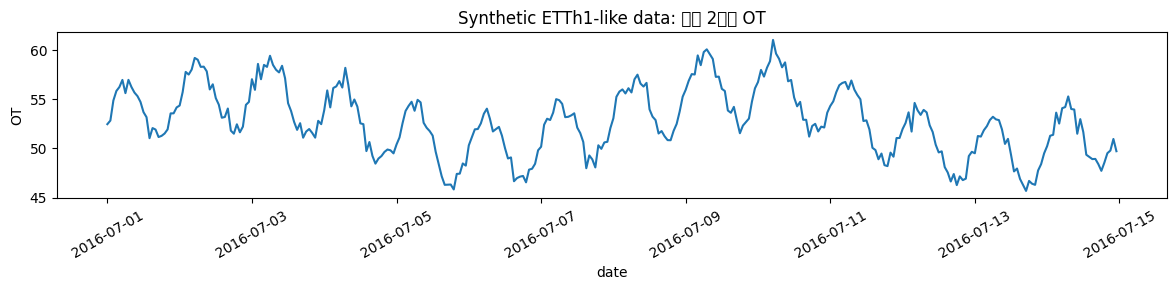

In [16]:
plt.figure(figsize=(12, 3))
plt.plot(pd.to_datetime(synthetic_df["date"]).iloc[:24*14], synthetic_df["OT"].iloc[:24*14])
plt.title("Synthetic ETTh1-like data: 처음 2주간 OT")
plt.xlabel("date")
plt.ylabel("OT")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# 6. TSLib 스타일의 `Dataset_ETT_hour`를 교육용으로 구현해보자

이제 핵심입니다.

우리가 만들 클래스는 아래 동작을 합니다.

1. CSV를 읽는다
2. `flag`에 따라 split border를 정한다
3. `features='S'/'M'/'MS'`에 맞게 컬럼을 고른다
4. train split으로만 scaler를 fit한다
5. `timeenc`에 따라 시간 특징을 만든다
6. `__getitem__`에서 `seq_x`, `seq_y`, `seq_x_mark`, `seq_y_mark`를 반환한다


In [18]:
@dataclass
class LoaderArgs:
    data: str = "ETTh1"
    root_path: str = "."
    data_path: str = "synthetic_ETTh1.csv"
    features: str = "M"     # 'S', 'M', 'MS'
    target: str = "OT"
    freq: str = "h"
    embed: str = "timeF"    # 'timeF'이면 timeenc=1
    seq_len: int = 96
    label_len: int = 48
    pred_len: int = 96
    batch_size: int = 32
    num_workers: int = 0
    augmentation_ratio: float = 0.0  # 교육용 구현에서는 사용하지 않음


def hourly_time_features_repo_like(dates):
    # TSLib timefeatures.py의 hourly branch 아이디어를 반영한 교육용 구현
    idx = pd.DatetimeIndex(pd.to_datetime(dates))
    hour = idx.hour / 23.0 - 0.5
    weekday = idx.dayofweek / 6.0 - 0.5
    day = (idx.day - 1) / 30.0 - 0.5
    day_of_year = (idx.dayofyear - 1) / 365.0 - 0.5
    return np.vstack([hour, weekday, day, day_of_year]).T.astype(np.float32)


class DatasetETTHourExplained(Dataset):
    def __init__(
        self,
        args,
        root_path,
        flag="train",
        size=None,
        features="S",
        data_path="ETTh1.csv",
        target="OT",
        scale=True,
        timeenc=0,
        freq="h",
    ):
        assert flag in ["train", "val", "test"]

        self.args = args
        self.root_path = root_path
        self.flag = flag
        self.features = features
        self.data_path = data_path
        self.target = target
        self.scale = scale
        self.timeenc = timeenc
        self.freq = freq

        # TSLib data_loader.py의 기본값
        if size is None:
            self.seq_len = 24 * 4 * 4
            self.label_len = 24 * 4
            self.pred_len = 24 * 4
        else:
            self.seq_len = size[0]
            self.label_len = size[1]
            self.pred_len = size[2]

        type_map = {"train": 0, "val": 1, "test": 2}
        self.set_type = type_map[flag]

        self.__read_data__()

    def __read_data__(self):
        self.scaler = StandardScaler()

        csv_path = Path(self.root_path) / self.data_path
        if not csv_path.exists():
            raise FileNotFoundError(
                f"{csv_path} 를 찾지 못했습니다. "
                "먼저 synthetic_ETTh1.csv를 생성했는지 확인하세요."
            )

        df_raw = pd.read_csv(csv_path)

        if "date" not in df_raw.columns:
            raise ValueError("CSV에 'date' 컬럼이 필요합니다.")
        if self.target not in df_raw.columns:
            raise ValueError(f"CSV에 target='{self.target}' 컬럼이 필요합니다.")

        # TSLib의 ETT_hour split 수치
        border1s = [
            0,
            12 * 30 * 24 - self.seq_len,
            12 * 30 * 24 + 4 * 30 * 24 - self.seq_len,
        ]
        border2s = [
            12 * 30 * 24,
            12 * 30 * 24 + 4 * 30 * 24,
            12 * 30 * 24 + 8 * 30 * 24,
        ]

        if len(df_raw) < border2s[-1]:
            raise ValueError(
                f"ETT_hour 로직은 최소 {border2s[-1]}행을 기대합니다. "
                f"현재 CSV 길이={len(df_raw)}"
            )

        border1 = border1s[self.set_type]
        border2 = border2s[self.set_type]

        # features 모드
        if self.features in ["M", "MS"]:
            cols_data = df_raw.columns[1:]   # date 제외
            df_data = df_raw[cols_data]
        elif self.features == "S":
            df_data = df_raw[[self.target]]
        else:
            raise ValueError("features는 'S', 'M', 'MS' 중 하나여야 합니다.")

        # scale은 train split으로만 fit
        if self.scale:
            train_data = df_data[border1s[0]:border2s[0]]
            self.scaler.fit(train_data.values)
            data = self.scaler.transform(df_data.values).astype(np.float32)
        else:
            data = df_data.values.astype(np.float32)

        # time mark
        df_stamp = df_raw[["date"]][border1:border2].copy()
        df_stamp["date"] = pd.to_datetime(df_stamp["date"])

        if self.timeenc == 0:
            df_stamp["month"] = df_stamp["date"].dt.month
            df_stamp["day"] = df_stamp["date"].dt.day
            df_stamp["weekday"] = df_stamp["date"].dt.weekday
            df_stamp["hour"] = df_stamp["date"].dt.hour
            data_stamp = df_stamp[["month", "day", "weekday", "hour"]].to_numpy(dtype=np.float32)
        elif self.timeenc == 1:
            if self.freq.lower() not in ["h", "1h"]:
                raise NotImplementedError("이 교육용 노트북은 hourly freq만 다룹니다.")
            data_stamp = hourly_time_features_repo_like(df_stamp["date"])
        else:
            raise ValueError("timeenc는 0 또는 1이어야 합니다.")

        self.data_x = data[border1:border2]
        self.data_y = data[border1:border2]
        self.data_stamp = data_stamp

        # 설명용으로 split 경계도 저장
        self.border1 = border1
        self.border2 = border2

    def __getitem__(self, index):
        s_begin = index
        s_end = s_begin + self.seq_len

        r_begin = s_end - self.label_len
        r_end = r_begin + self.label_len + self.pred_len

        seq_x = self.data_x[s_begin:s_end]
        seq_y = self.data_y[r_begin:r_end]
        seq_x_mark = self.data_stamp[s_begin:s_end]
        seq_y_mark = self.data_stamp[r_begin:r_end]

        return seq_x, seq_y, seq_x_mark, seq_y_mark

    def __len__(self):
        return len(self.data_x) - self.seq_len - self.pred_len + 1

    def inverse_transform(self, data):
        return self.scaler.inverse_transform(data)


## 6-1. 클래스 내부 default size를 직접 확인해보자

`size=None`이면 클래스 내부 기본값(`384/96/96`)이 쓰입니다.


In [19]:
args = LoaderArgs(data_path=str(synthetic_path))

default_ds = DatasetETTHourExplained(
    args=args,
    root_path=".",
    flag="train",
    size=None,            # <- 클래스 내부 기본값 사용
    features="M",
    data_path=str(synthetic_path),
    target="OT",
    scale=True,
    timeenc=1,
    freq="h",
)

print("size=None일 때:")
print("  seq_len  =", default_ds.seq_len)
print("  label_len=", default_ds.label_len)
print("  pred_len =", default_ds.pred_len)
print("  len(dataset) =", len(default_ds))


size=None일 때:
  seq_len  = 384
  label_len= 96
  pred_len = 96
  len(dataset) = 8161


## 6-2. 실제 학습처럼 `size=[seq_len, label_len, pred_len]`를 넘겨보자

보통은 `data_provider()`가 이 값을 명시적으로 넘겨줍니다.  
즉, 실제 실험에서는 아래처럼 CLI/args 값이 적용된다고 생각하면 됩니다.


In [20]:
cli_like_args = LoaderArgs(
    data="ETTh1",
    root_path=".",
    data_path=str(synthetic_path),
    features="M",
    target="OT",
    freq="h",
    embed="timeF",
    seq_len=96,
    label_len=48,
    pred_len=96,
    batch_size=16,
    num_workers=0,
)

train_ds = DatasetETTHourExplained(
    args=cli_like_args,
    root_path=cli_like_args.root_path,
    flag="train",
    size=[cli_like_args.seq_len, cli_like_args.label_len, cli_like_args.pred_len],
    features=cli_like_args.features,
    data_path=cli_like_args.data_path,
    target=cli_like_args.target,
    scale=True,
    timeenc=1,
    freq=cli_like_args.freq,
)

print("실제 학습처럼 size를 넘겼을 때:")
print("  seq_len  =", train_ds.seq_len)
print("  label_len=", train_ds.label_len)
print("  pred_len =", train_ds.pred_len)
print("  border1, border2 =", train_ds.border1, train_ds.border2)
print("  len(dataset) =", len(train_ds))


실제 학습처럼 size를 넘겼을 때:
  seq_len  = 96
  label_len= 48
  pred_len = 96
  border1, border2 = 0 8640
  len(dataset) = 8449


In [21]:
seq_x, seq_y, seq_x_mark, seq_y_mark = train_ds[0]

print("첫 샘플의 shape")
print("  seq_x      :", seq_x.shape)
print("  seq_y      :", seq_y.shape)
print("  seq_x_mark :", seq_x_mark.shape)
print("  seq_y_mark :", seq_y_mark.shape)

print("\nseq_x 첫 3행")
display(pd.DataFrame(seq_x[:3], columns=["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]).round(3))

print("seq_x_mark 첫 3행")
display(pd.DataFrame(seq_x_mark[:3], columns=["hour_norm", "weekday_norm", "day_norm", "dayofyear_norm"]).round(3))


첫 샘플의 shape
  seq_x      : (96, 7)
  seq_y      : (144, 7)
  seq_x_mark : (96, 4)
  seq_y_mark : (144, 4)

seq_x 첫 3행


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,0.029,0.183,-0.043,0.141,-0.056,-0.236,-0.157
1,0.245,0.341,0.333,0.389,-0.141,0.119,-0.051
2,0.760,0.524,0.800,0.338,0.336,0.781,0.548


seq_x_mark 첫 3행


,hour_norm,weekday_norm,day_norm,dayofyear_norm
0,-0.500,0.167,-0.5,-0.001
1,-0.457,0.167,-0.5,-0.001
2,-0.413,0.167,-0.5,-0.001


### shape를 해석해보자

현재 설정은:

- `features='M'` → 7개 변수 모두 사용
- `seq_len=96`
- `label_len=48`
- `pred_len=96`
- `timeenc=1` with hourly → 시간 특징 차원 4

그래서:

- `seq_x.shape == (96, 7)`
- `seq_y.shape == (144, 7)`  ← `48 + 96`
- `seq_x_mark.shape == (96, 4)`
- `seq_y_mark.shape == (144, 4)`

가 됩니다.


In [22]:
val_ds = DatasetETTHourExplained(
    args=cli_like_args,
    root_path=".",
    flag="val",
    size=[cli_like_args.seq_len, cli_like_args.label_len, cli_like_args.pred_len],
    features=cli_like_args.features,
    data_path=cli_like_args.data_path,
    target=cli_like_args.target,
    scale=True,
    timeenc=1,
    freq=cli_like_args.freq,
)

test_ds = DatasetETTHourExplained(
    args=cli_like_args,
    root_path=".",
    flag="test",
    size=[cli_like_args.seq_len, cli_like_args.label_len, cli_like_args.pred_len],
    features=cli_like_args.features,
    data_path=cli_like_args.data_path,
    target=cli_like_args.target,
    scale=True,
    timeenc=1,
    freq=cli_like_args.freq,
)

summary_df = pd.DataFrame({
    "split": ["train", "val", "test"],
    "border1": [train_ds.border1, val_ds.border1, test_ds.border1],
    "border2": [train_ds.border2, val_ds.border2, test_ds.border2],
    "len(data_x)": [len(train_ds.data_x), len(val_ds.data_x), len(test_ds.data_x)],
    "len(dataset)": [len(train_ds), len(val_ds), len(test_ds)],
})
display(summary_df)


,split,border1,border2,len(data_x),len(dataset)
0,train,0,8640,8640,8449
1,val,8544,11520,2976,2785
2,test,11424,14400,2976,2785


`val` 과 `test`의 `border1`이 `seq_len`만큼 앞당겨져 있는 것을 꼭 보세요.

이 덕분에 validation/test의 첫 샘플도 **충분한 과거 입력 구간**을 가질 수 있습니다.


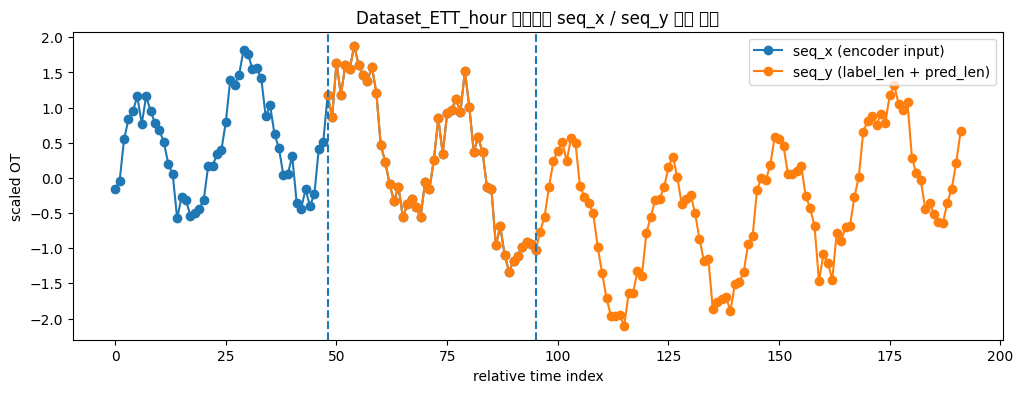

seq_x 길이 = 96
seq_y 길이 = 144 = label_len + pred_len = 144
seq_y 앞부분(label_len) 길이 = 48
seq_y 뒷부분(pred_len) 길이 = 96


In [23]:
# 첫 샘플에서 seq_x와 seq_y가 어떻게 겹치는지 target(OT)만 뽑아 시각화해보자.
seq_x, seq_y, seq_x_mark, seq_y_mark = train_ds[0]

target_idx = -1  # OT가 마지막 컬럼
x_vals = seq_x[:, target_idx]
y_vals = seq_y[:, target_idx]

x_time = np.arange(train_ds.seq_len)
y_time = np.arange(train_ds.seq_len - train_ds.label_len, train_ds.seq_len + train_ds.pred_len)

plt.figure(figsize=(12, 4))
plt.plot(x_time, x_vals, marker="o", label="seq_x (encoder input)")
plt.plot(y_time, y_vals, marker="o", label="seq_y (label_len + pred_len)")
plt.axvline(train_ds.seq_len - train_ds.label_len, linestyle="--")
plt.axvline(train_ds.seq_len - 1, linestyle="--")
plt.title("Dataset_ETT_hour 스타일의 seq_x / seq_y 겹침 구조")
plt.xlabel("relative time index")
plt.ylabel("scaled OT")
plt.legend()
plt.show()

print("seq_x 길이 =", len(x_vals))
print("seq_y 길이 =", len(y_vals), "= label_len + pred_len =", train_ds.label_len + train_ds.pred_len)
print("seq_y 앞부분(label_len) 길이 =", train_ds.label_len)
print("seq_y 뒷부분(pred_len) 길이 =", train_ds.pred_len)


# 7. `features='S'`, `'M'`, `'MS'`는 어떻게 다를까?

- `S`: **univariate → univariate**
  - target 하나만 읽음
- `M`: **multivariate → multivariate**
  - 모든 변수 읽음, 모든 변수를 예측 대상으로 둠
- `MS`: **multivariate → univariate**
  - 입력은 모든 변수
  - 하지만 **loss 계산에서는 target 하나만 사용**

주의할 점: `MS`에서도 dataset 단계에서는 보통 **모든 변수**를 읽습니다.  
그 다음 학습 루프에서 `f_dim = -1` 같은 방식으로 **마지막 target 채널만** 잘라 loss를 계산합니다.


In [24]:
def build_dataset_for_feature_mode(feature_mode):
    args_mode = LoaderArgs(
        data="ETTh1",
        root_path=".",
        data_path=str(synthetic_path),
        features=feature_mode,
        target="OT",
        freq="h",
        embed="timeF",
        seq_len=96,
        label_len=48,
        pred_len=96,
        batch_size=8,
        num_workers=0,
    )
    ds = DatasetETTHourExplained(
        args=args_mode,
        root_path=args_mode.root_path,
        flag="train",
        size=[args_mode.seq_len, args_mode.label_len, args_mode.pred_len],
        features=args_mode.features,
        data_path=args_mode.data_path,
        target=args_mode.target,
        scale=True,
        timeenc=1,
        freq=args_mode.freq,
    )
    sample = ds[0]
    return args_mode, ds, sample

rows = []
for mode in ["S", "M", "MS"]:
    args_mode, ds_mode, sample_mode = build_dataset_for_feature_mode(mode)
    rows.append({
        "features mode": mode,
        "seq_x shape": sample_mode[0].shape,
        "seq_y shape": sample_mode[1].shape,
        "seq_x_mark shape": sample_mode[2].shape,
        "seq_y_mark shape": sample_mode[3].shape,
    })

display(pd.DataFrame(rows))


,features mode,seq_x shape,seq_y shape,seq_x_mark shape,seq_y_mark shape
0,S,"(96, 1)","(144, 1)","(96, 4)","(144, 4)"
1,M,"(96, 7)","(144, 7)","(96, 4)","(144, 4)"
2,MS,"(96, 7)","(144, 7)","(96, 4)","(144, 4)"


In [25]:
# MS 모드에서 "dataset은 다변량을 읽지만, 학습 loss는 target 하나만 고른다"를 확인하자.
ms_args, ms_ds, _ = build_dataset_for_feature_mode("MS")
ms_loader = DataLoader(ms_ds, batch_size=4, shuffle=False)

batch_x, batch_y, batch_x_mark, batch_y_mark = next(iter(ms_loader))

print("MS mode batch_x shape:", batch_x.shape)
print("MS mode batch_y shape:", batch_y.shape)

f_dim = -1 if ms_args.features == "MS" else 0
target_slice = batch_y[:, -ms_args.pred_len:, f_dim:]

print("loss 계산에 사용할 target_slice shape:", target_slice.shape)
print("=> 마지막 채널(target='OT') 하나만 남는다.")


MS mode batch_x shape: torch.Size([4, 96, 7])
MS mode batch_y shape: torch.Size([4, 144, 7])
loss 계산에 사용할 target_slice shape: torch.Size([4, 96, 1])
=> 마지막 채널(target='OT') 하나만 남는다.


### 여기서 한 번 더 정리

`MS` 모드에서 자주 하는 오해:

> “그럼 dataset이 target 하나만 반환하나요?”

아닙니다.  
TSLib 스타일에서는 보통 **dataset은 전체 변수**를 반환하고,  
학습 루프 쪽에서 **마지막 target 채널만 잘라서 loss** 를 계산합니다.

그래서 `MS`를 제대로 쓰려면,  
**target 컬럼이 어떤 위치에 있는지** 를 이해하는 것이 중요합니다.

ETT 계열은 `OT`가 마지막 컬럼이라 이 방식이 자연스럽게 맞아떨어집니다.


> 실무/응용 메모  
> `ETT_hour`에서는 `OT`가 마지막 컬럼이라 `MS` 모드에서 마지막 채널을 target으로 잘라 쓰는 방식이 자연스럽습니다.  
> 반면 **임의의 custom 데이터**에서는 target 컬럼 위치를 명확히 관리해야 하며,  
> 그래서 TSLib의 `Dataset_Custom`은 보통 target 컬럼을 뒤로 재배치한 뒤 사용합니다.


# 8. `data_provider()`는 무슨 역할을 할까?

원문 `data_provider/data_factory.py`는 대략 이런 일을 합니다.

1. `args.data`를 보고 어떤 Dataset 클래스를 쓸지 고른다
2. `args.embed != 'timeF'` 이면 `timeenc=0`, 아니면 `timeenc=1`
3. `flag`에 따라 shuffle 여부를 정한다
4. Dataset을 만들고
5. DataLoader로 감싼다

즉, dataset 클래스만 이해하면 끝이 아니라,  
**실제 실험에서는 `data_provider()`가 어떻게 dataset을 호출하는지** 까지 봐야 합니다.


In [ ]:
data_dict_explained = {
    "ETTh1": DatasetETTHourExplained,
    "ETTh2": DatasetETTHourExplained,  # 교육용으로 같은 클래스를 재사용
}

def data_provider_like_repo(args, flag):
    Data = data_dict_explained[args.data]
    timeenc = 0 if args.embed != "timeF" else 1
    shuffle_flag = False if flag.lower() == "test" else True
    drop_last = False

    dataset = Data(
        args=args,
        root_path=args.root_path,
        flag=flag,
        size=[args.seq_len, args.label_len, args.pred_len],
        features=args.features,
        data_path=args.data_path,
        target=args.target,
        scale=True,
        timeenc=timeenc,
        freq=args.freq,
    )

    loader = DataLoader(
        dataset,
        batch_size=args.batch_size,
        shuffle=shuffle_flag,
        num_workers=args.num_workers,
        drop_last=drop_last,
    )
    return dataset, loader

train_set, train_loader = data_provider_like_repo(cli_like_args, "train")
test_set, test_loader = data_provider_like_repo(cli_like_args, "test")

print("train shuffle=True, test shuffle=False 인 흐름을 사용")
print("len(train_set) =", len(train_set))
print("len(test_set)  =", len(test_set))


In [ ]:
batch_x, batch_y, batch_x_mark, batch_y_mark = next(iter(train_loader))

print("DataLoader가 만들어 준 실제 batch")
print("  type(batch_x):", type(batch_x))
print("  type(batch_y):", type(batch_y))
print("  batch_x shape     :", batch_x.shape)
print("  batch_y shape     :", batch_y.shape)
print("  batch_x_mark shape:", batch_x_mark.shape)
print("  batch_y_mark shape:", batch_y_mark.shape)


여기서 아주 중요한 관찰:

우리는 `Dataset` 안에서 `numpy.ndarray`를 반환했지만,  
`DataLoader`의 기본 collate가 그것들을 모아서 **`torch.Tensor` batch** 로 바꿔줍니다.

즉, 많은 초보자들이 헷갈리는 “도대체 언제 tensor가 되지?”에 대한 답은:

> 대개 `DataLoader`가 batch를 만들 때 자동으로 tensor로 바꿔준다.

입니다.


# 9. `label_len`은 학습 루프에서 어떻게 쓰일까?

`Dataset_ETT_hour`만 보면 `label_len`이 왜 필요한지 감이 약할 수 있습니다.

그 이유는 학습 루프에서 보통 decoder input을 이렇게 만들기 때문입니다.

1. `batch_y`의 앞 `label_len` 구간은 **실제 과거 값**
2. 뒤 `pred_len` 구간은 **0으로 채운 자리**
3. 둘을 이어 붙여 `dec_inp`를 만든다

즉 decoder는 “과거 일부 실제 값 + 앞으로 채워야 할 빈칸”을 받고 예측합니다.


In [ ]:
batch_x, batch_y, batch_x_mark, batch_y_mark = next(iter(train_loader))

dec_inp = torch.zeros_like(batch_y[:, -cli_like_args.pred_len:, :]).float()
dec_inp = torch.cat([batch_y[:, :cli_like_args.label_len, :], dec_inp], dim=1).float()

print("batch_y shape :", batch_y.shape)
print("dec_inp shape :", dec_inp.shape)
print()
print("앞쪽 label_len 길이 :", cli_like_args.label_len)
print("뒤쪽 pred_len 길이  :", cli_like_args.pred_len)
print("합계 =", cli_like_args.label_len + cli_like_args.pred_len)


In [ ]:
# 한 샘플만 뽑아 target(OT) 관점에서 decoder input을 보자.
sample_batch_y = batch_y[0, :, -1].numpy()
sample_dec_inp = dec_inp[0, :, -1].numpy()

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(sample_batch_y)), sample_batch_y, marker="o", label="batch_y target")
plt.plot(np.arange(len(sample_dec_inp)), sample_dec_inp, marker="o", label="dec_inp target")
plt.axvline(cli_like_args.label_len - 1, linestyle="--")
plt.title("decoder input은 앞쪽 label_len은 실제값, 뒤쪽 pred_len은 0")
plt.xlabel("decoder time index")
plt.ylabel("scaled OT")
plt.legend()
plt.show()

print("batch_y 앞 10개:", np.round(sample_batch_y[:10], 3))
print("dec_inp 앞 10개:", np.round(sample_dec_inp[:10], 3))
print("dec_inp 뒤 10개:", np.round(sample_dec_inp[-10:], 3))


## 9-1. 아주 작은 end-to-end 훈련 step 흉내내기

실제 TSLib 모델은 더 복잡하지만,  
**dataloader 출력이 학습 루프로 어떻게 이어지는지** 한 번 끝까지 보는것은 도움이 됩니다.

아래 더미 모델은:

- encoder 입력 `batch_x`를 받아
- 간단한 선형층으로
- `pred_len` 길이의 target 하나만 예측

하도록 만든 **설명용 모델**입니다.


In [ ]:
ms_args = LoaderArgs(
    data="ETTh1",
    root_path=".",
    data_path=str(synthetic_path),
    features="MS",
    target="OT",
    freq="h",
    embed="timeF",
    seq_len=96,
    label_len=48,
    pred_len=96,
    batch_size=8,
    num_workers=0,
)

ms_set, ms_loader = data_provider_like_repo(ms_args, "train")
batch_x, batch_y, batch_x_mark, batch_y_mark = next(iter(ms_loader))

# MS 모드에서는 마지막 target 채널만 loss 대상으로 쓴다.
target_y = batch_y[:, -ms_args.pred_len:, -1:].float()

class DummyForecastModel(nn.Module):
    def __init__(self, seq_len, input_dim, pred_len, c_out=1):
        super().__init__()
        self.seq_len = seq_len
        self.input_dim = input_dim
        self.pred_len = pred_len
        self.c_out = c_out
        self.proj = nn.Linear(seq_len * input_dim, pred_len * c_out)

    def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec):
        B = x_enc.shape[0]
        out = self.proj(x_enc.reshape(B, -1))
        return out.reshape(B, self.pred_len, self.c_out)

dummy_model = DummyForecastModel(
    seq_len=ms_args.seq_len,
    input_dim=batch_x.shape[-1],
    pred_len=ms_args.pred_len,
    c_out=1,
)

dec_inp = torch.zeros_like(batch_y[:, -ms_args.pred_len:, :]).float()
dec_inp = torch.cat([batch_y[:, :ms_args.label_len, :], dec_inp], dim=1).float()

pred = dummy_model(batch_x.float(), batch_x_mark.float(), dec_inp.float(), batch_y_mark.float())

criterion = nn.MSELoss()
loss = criterion(pred, target_y)

print("batch_x shape :", batch_x.shape)
print("target_y shape:", target_y.shape)
print("pred shape    :", pred.shape)
print("dummy loss    :", float(loss))


# 10. 포인트 정리

## 1) 왜 validation/test 시작점이 split 시작점이 아니라 `-seq_len` 되어 있나요?

validation/test의 **첫 샘플도 입력 구간이 필요**하기 때문입니다.  
예를 들어 validation이 8640에서 시작한다고 해도,  
첫 validation 샘플의 encoder 입력을 만들려면 그 직전 96개 시점이 필요합니다.

---

## 2) 왜 `seq_y` 길이가 `pred_len`이 아니라 `label_len + pred_len`인가요?

decoder가 바로 미래만 보는 것이 아니라,  
앞쪽 `label_len` 길이의 **실제 과거 값**을 참고해 시작하기 때문입니다.

---

## 3) 왜 scaling은 전체 데이터가 아니라 train으로만 fit하나요?

미래 분포를 미리 보면 데이터 누수입니다.  
평가가 부정확하게 좋아질 수 있습니다.

---

## 4) `MS` 모드인데 왜 dataset이 target 하나만 주지 않나요?

TSLib 스타일에서는 대개 dataset은 다변량 전체를 주고,  
학습 루프가 마지막 target 채널만 잘라서 loss를 계산합니다.

---

## 5) `timeenc=0`과 `timeenc=1`은 무엇이 다른가요?

- `timeenc=0`: 사람이 읽기 쉬운 범주형 느낌의 시간값
- `timeenc=1`: 모델 입력에 더 적합한 정규화된 연속형 시간 특징

---



# 11. 수업 중간 체크 질문

1. `__len__`에 왜 `label_len`은 직접 안 들어가고 `pred_len`만 들어갈까?
2. `seq_x`와 `seq_y`는 왜 일부가 겹칠까?
3. `features='MS'`일 때 dataset과 training loop의 책임 분담은 어떻게 될까?
4. validation/test split에서 `border1`을 왜 앞으로 당길까?
5. `timeenc=0` 대신 `timeenc=1`을 쓰는 이유는 무엇일까?


# 12. 실습 과제

## 실습 A
`seq_len=48`, `label_len=24`, `pred_len=24`로 바꾸고  
각 split에서 `len(dataset)`이 어떻게 바뀌는지 직접 계산하고 확인해보세요.

## 실습 B
`features='S'`, `'M'`, `'MS'`를 바꿔가며 `batch_x.shape`, `batch_y.shape`를 비교해보세요.

## 실습 C
`timeenc=0`과 `timeenc=1`의 `seq_x_mark`를 직접 출력해 차이를 설명해보세요.

## 실습 D
`scale=False`로 dataset을 만들고, `scale=True`와 값 범위가 어떻게 달라지는지 비교해보세요.

## 실습 E
synthetic 데이터 생성 함수를 수정해서 OT가 더 강한 trend를 갖게 만들고,  
scaling 전후 그래프를 비교해보세요.


<details>
<summary><strong>실습 A 힌트 보기</strong></summary>

- 각 split의 `data_x` 길이는 먼저 `border2 - border1`
- 그 다음 `len(dataset) = len(data_x) - seq_len - pred_len + 1`

즉, split을 잡고 나서 다시 window를 만들 수 있는 시작점 개수를 세는 구조입니다.
</details>

<details>
<summary><strong>실습 B 힌트 보기</strong></summary>

- `S`: target 하나만 읽으므로 feature 차원은 1
- `M`, `MS`: `date`를 제외한 모든 변수를 읽으므로 feature 차원은 7
- 단, `MS`는 training loop에서 마지막 target 채널만 골라 loss를 계산합니다.
</details>

<details>
<summary><strong>실습 C 힌트 보기</strong></summary>

- `timeenc=0`은 `(month, day, weekday, hour)`처럼 사람이 읽는 달력 값
- `timeenc=1`은 대개 `[-0.5, 0.5]` 근처로 정규화된 연속 특징
</details>


# 13. 한 장으로 요약!

1. `Dataset`은 샘플 1개 정의, `DataLoader`는 batching/shuffling 담당
2. 시계열 샘플 1개는 숫자 하나가 아니라 **window**
3. `seq_x`는 encoder 입력, `seq_y`는 `label_len + pred_len`
4. `seq_x_mark`, `seq_y_mark`는 시간 특징
5. split은 고정 수치로 나누고, validation/test는 `seq_len`만큼 앞을 포함
6. scaling은 train split으로만 fit
7. `MS` 모드에서는 dataset은 다변량을 내놓지만, loss는 target 채널만 사용



# 참고 자료

- [PyTorch Tutorial: Datasets & DataLoaders](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html)
- [PyTorch Reference: torch.utils.data](https://docs.pytorch.org/docs/stable/data.html)
- [TSLib `data_loader.py`](https://github.com/thuml/Time-Series-Library/blob/main/data_provider/data_loader.py)
- [TSLib `data_factory.py`](https://github.com/thuml/Time-Series-Library/blob/main/data_provider/data_factory.py)
- [TSLib `timefeatures.py`](https://github.com/thuml/Time-Series-Library/blob/main/utils/timefeatures.py)
- [TSLib `exp_long_term_forecasting.py`](https://github.com/thuml/Time-Series-Library/blob/main/exp/exp_long_term_forecasting.py)
- [TSLib README](https://github.com/thuml/Time-Series-Library)
- [ETDataset README](https://github.com/zhouhaoyi/ETDataset)
